In [103]:
import pandas as pd

In [104]:
df = pd.read_csv("C:/Users/DELL/OneDrive/Desktop/India Inflation Intelligence System/CPI_2012_2025.csv")

In [105]:
df.head()

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
0,2012,2025,12,December,All India,Rural,Consumer Food Price,Consumer Food Price-Overall,198.5,-3.03,F
1,2012,2025,12,December,All India,Rural,Miscellaneous,Recreation and Amusement,183.4,1.05,F
2,2012,2025,12,December,All India,Rural,Miscellaneous,Transport and Communication,178.5,1.02,F
3,2012,2025,12,December,All India,Rural,Miscellaneous,Health,207.0,3.40,F
4,2012,2025,12,December,All India,Rural,Miscellaneous,Household Goods and Services,189.8,1.50,F


In [106]:
df.tail()


,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
379300,2012,2011,1,January,West Bengal,Combined,Food and Beverages,Oils and Fats,75.7,NaN,F
379301,2012,2011,1,January,West Bengal,Combined,Food and Beverages,Fruits,83.8,NaN,F
379302,2012,2011,1,January,West Bengal,Combined,Food and Beverages,Vegetables,103.9,NaN,F
379303,2012,2011,1,January,West Bengal,Combined,Food and Beverages,Meat and Fish,84.8,NaN,F
379304,2012,2011,1,January,West Bengal,Combined,General,General-Overall,88.3,NaN,F


In [107]:
df.columns

Index(['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group',
       'subgroup', 'index', 'inflation', 'status'],
      dtype='object')

In [108]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379305 entries, 0 to 379304
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   baseyear    379305 non-null  int64  
 1   year        379305 non-null  int64  
 2   month_code  379305 non-null  int64  
 3   month       379305 non-null  object 
 4   state       379305 non-null  object 
 5   sector      379305 non-null  object 
 6   group       379305 non-null  object 
 7   subgroup    379305 non-null  object 
 8   index       364338 non-null  float64
 9   inflation   308534 non-null  float64
 10  status      379305 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 31.8+ MB


In [109]:
df.isnull().sum()

#We won't fill the inflation with mean or median because we do not need it and also
#CPI is a time series data so we cannot use mean or median here

baseyear          0
year              0
month_code        0
month             0
state             0
sector            0
group             0
subgroup          0
index         14967
inflation     70771
status            0
dtype: int64

In [110]:
df.shape

(379305, 11)

In [111]:
df_combined = df[df['sector'] == 'Combined']
df_general = df_combined[df_combined['subgroup'] == 'General-Overall']

df_general['index'].isnull().sum()

np.int64(173)

In [112]:
#We need to understand where nulls exist.
df_general[df_general['index'].isnull()].head(10)

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
203,2012,2025,12,December,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
2360,2012,2025,11,November,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
4517,2012,2025,10,October,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
6674,2012,2025,9,September,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
8831,2012,2025,8,August,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
10988,2012,2025,7,July,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
13145,2012,2025,6,June,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
15302,2012,2025,5,May,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
17459,2012,2025,4,April,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
19616,2012,2025,3,March,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F


In [113]:
df_general['year'].value_counts().sort_index()

year
2011    444
2012    444
2013    629
2014    444
2015    444
2016    444
2017    444
2018    444
2019    444
2020    369
2021    444
2022    444
2023    444
2024    444
2025    444
Name: count, dtype: int64

In [114]:
#To calculate number of states
df_general['state'].nunique()

37

In [115]:
df_general[df_general['year'] == 2013]['state'].value_counts().head()

state
All India      17
Lakshadweep    17
Maharashtra    17
Manipur        17
Meghalaya      17
Name: count, dtype: int64

In [116]:
df_general[df_general['year'] == 2020]['state'].value_counts().head()

state
All India         12
Punjab            10
Lakshadweep       10
Madhya Pradesh    10
Maharashtra       10
Name: count, dtype: int64

In [117]:
'''
# Step 1: Filter rows where year is 2013
# Step 2: From those rows, check number of unique months
# Expected result: 12 (Jan–Dec)
# If >12 → duplicate month entries
# If <12 → missing month data
'''
df[df['year'] == 2013]['month'].nunique()

12

In [118]:
# Check what status values exist in 2013
df[df['year'] == 2013]['status'].unique()

array(['F'], dtype=object)

In [119]:
#TO check the unique baseyear for year 2013
df[df['year'] == 2013]['baseyear'].unique()

array([2012])

In [120]:
#TO check how many unique states exist for year 2013
df[df['year'] == 2013]['state'].nunique()

37

In [121]:
#To check how many rows exist for year = 2013 & state = 'ALl India'
len(df_general[(df_general['year'] == 2013) &  (df_general['state'] == 'All India')])

17

In [122]:
# Display all rows for year 2013 and state 'All India'
# to inspect why there are 17 entries instead of expected 12
df_general[(df_general['year'] == 2013) & (df_general['state'] == 'All India')]

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
300641,2012,2013,12,December,All India,Combined,General,General-Overall,114.5,NaN,F
302798,2012,2013,11,November,All India,Combined,General,General-Overall,116.3,NaN,F
304955,2012,2013,10,October,All India,Combined,General,General-Overall,114.8,NaN,F
307112,2012,2013,9,September,All India,Combined,General,General-Overall,113.7,NaN,F
309269,2012,2013,8,August,All India,Combined,General,General-Overall,112.4,NaN,F
311426,2012,2013,7,July,All India,Combined,General,General-Overall,111.0,NaN,F
313583,2012,2013,6,June,All India,Combined,General,General-Overall,109.3,NaN,F
315745,2012,2013,5,May,All India,Combined,General,General-Overall,106.9,NaN,F
315746,2012,2013,5,May,All India,Combined,General,General-Overall,107.5,9.03,F
318121,2012,2013,4,April,All India,Combined,General,General-Overall,106.7,9.10,F


In [123]:
# Keep only rows where inflation is NaN.
# These rows contain the raw CPI index values.
# Rows where inflation is present are derived records used for inflation calculation.
df_clean = df_general[df_general['inflation'].isnull()]

In [124]:
# Verify that after removing duplicate CPI rows,
# each year contains exactly 12 unique months

df_clean[df_clean['year'] == 2013]['month'].nunique()

12

In [125]:
# Combine year and month_code to create a proper datetime column
# Day is set to 1 since CPI data is monthly
df_clean['date'] = pd.to_datetime(dict(year=df_clean['year'], month=df_clean['month_code'],day=1))

C:\Users\DELL\AppData\Local\Temp\ipykernel_17124\1253400424.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = pd.to_datetime(dict(year=df_clean['year'], month=df_clean['month_code'],day=1))


In [126]:
df_clean.head()

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status,date
203,2012,2025,12,December,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F,2025-12-01
2360,2012,2025,11,November,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F,2025-11-01
4517,2012,2025,10,October,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F,2025-10-01
6674,2012,2025,9,September,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F,2025-09-01
8831,2012,2025,8,August,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F,2025-08-01


In [127]:
df_clean[['date','state','index']].head()

,date,state,index
203,2025-12-01,Arunachal Pradesh,NaN
2360,2025-11-01,Arunachal Pradesh,NaN
4517,2025-10-01,Arunachal Pradesh,NaN
6674,2025-09-01,Arunachal Pradesh,NaN
8831,2025-08-01,Arunachal Pradesh,NaN


In [128]:
df_states['state'].nunique()

36

In [129]:
# For each state, extract the first and last CPI index value
#We used first and last to use first and last CPI value of that particular state
cpi_growth = df_states.groupby('state')['index'].agg(['first','last'])
cpi_growth.head()

,first,last
state,,
Andaman & Nicobar Islands,200.3,93.5
Andhra Pradesh,204.9,90.6
Arunachal Pradesh,158.8,147.9
Assam,197.0,87.1
Bihar,194.1,89.5


In [132]:
# Select top 5 states with highest CPI growth
top5_states = cpi_growth.head(5)

In [133]:
cpi_growth.head()

,first,last,growth_percent
state,,,
Arunachal Pradesh,158.8,147.9,-6.863980
Delhi,173.5,88.4,-49.048991
Himachal Pradesh,185.7,91.5,-50.726979
Dadra & Nagar Haveli,188.6,92.8,-50.795334
Goa,189.1,92.3,-51.189847


In [134]:
df_states.shape

(6405, 11)

In [135]:
df_states['state'].nunique()

36

In [136]:
df_states['year'].unique()

array([2025, 2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015,
       2014, 2013, 2012, 2011])

In [137]:
df_states['state'].value_counts().head()

state
Andaman & Nicobar Islands    178
Kerala                       178
Uttar Pradesh                178
Uttarakhand                  178
Tripura                      178
Name: count, dtype: int64

In [138]:
df_states['year'].value_counts().sort_index()

year
2011    432
2012    432
2013    432
2014    432
2015    432
2016    432
2017    432
2018    432
2019    432
2020    357
2021    432
2022    432
2023    432
2024    432
2025    432
Name: count, dtype: int64

In [139]:
# Remove duplicate CPI records for the same state, year, and month
# Some months appear twice due to inflation calculation rows
# Keeping the first occurrence preserves the raw CPI index
df_clean = df_general.drop_duplicates(
    subset=['state', 'year', 'month_code'],
    keep='first'
)

In [140]:
df_clean.head()
df_clean['year'].value_counts().sort_index()

year
2011    444
2012    444
2013    444
2014    444
2015    444
2016    444
2017    444
2018    444
2019    444
2020    369
2021    444
2022    444
2023    444
2024    444
2025    444
Name: count, dtype: int64

In [141]:
df_states.shape

(6405, 11)

In [142]:
df_clean

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
83,2012,2025,12,December,All India,Combined,General,General-Overall,198.0,1.33,F
104,2012,2025,12,December,Andaman & Nicobar Islands,Combined,General,General-Overall,200.3,0.70,F
185,2012,2025,12,December,Andhra Pradesh,Combined,General,General-Overall,204.9,2.71,F
203,2012,2025,12,December,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
284,2012,2025,12,December,Assam,Combined,General,General-Overall,197.0,-1.20,F
...,...,...,...,...,...,...,...,...,...,...,...
379040,2012,2011,1,January,Telangana,Combined,General,General-Overall,88.3,NaN,F
379061,2012,2011,1,January,Tripura,Combined,General,General-Overall,99.3,NaN,F
379142,2012,2011,1,January,Uttarakhand,Combined,General,General-Overall,89.2,NaN,F
379223,2012,2011,1,January,Uttar Pradesh,Combined,General,General-Overall,89.2,NaN,F


In [148]:
df_states.head()

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status
104,2012,2025,12,December,Andaman & Nicobar Islands,Combined,General,General-Overall,200.3,0.70,F
185,2012,2025,12,December,Andhra Pradesh,Combined,General,General-Overall,204.9,2.71,F
203,2012,2025,12,December,Arunachal Pradesh,Combined,General,General-Overall,NaN,NaN,F
284,2012,2025,12,December,Assam,Combined,General,General-Overall,197.0,-1.20,F
365,2012,2025,12,December,Bihar,Combined,General,General-Overall,194.1,-1.37,F


In [149]:
# create date column
df_clean['date'] = pd.to_datetime(dict(year=df_clean['year'],
                                       month=df_clean['month_code'],
                                       day=1))

C:\Users\DELL\AppData\Local\Temp\ipykernel_17124\1519867986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = pd.to_datetime(dict(year=df_clean['year'],


In [150]:
#To perform State-wise CPI trends comparison
# Remove "All India" since it is a national aggregate
# We only want individual states for state-wise CPI analysis
df_states = df_clean[df_clean['state'] != 'All India']

In [151]:
# Sort by state and date so time-series calculations work correctly
#Sort dataset by state and date so first() and last() return correct values
df_states = df_states.sort_values(['state','date'])

In [152]:
df_states.columns

Index(['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group',
       'subgroup', 'index', 'inflation', 'status', 'date'],
      dtype='object')

In [153]:
# For each state, extract the first and last CPI index value
#We used first and last to use first and last CPI value of that particular state
cpi_growth = df_states.groupby('state')['index'].agg(['first','last'])
cpi_growth.head()

,first,last
state,,
Andaman & Nicobar Islands,93.5,200.3
Andhra Pradesh,90.6,204.9
Arunachal Pradesh,147.9,158.8
Assam,87.1,197.0
Bihar,89.5,194.1


In [154]:
# Calculate overall CPI growth percentage for each state
cpi_growth['growth_percent'] = ((cpi_growth['last'] - cpi_growth['first']) / cpi_growth['first']) * 100
cpi_growth.head()

,first,last,growth_percent
state,,,
Andaman & Nicobar Islands,93.5,200.3,114.224599
Andhra Pradesh,90.6,204.9,126.158940
Arunachal Pradesh,147.9,158.8,7.369844
Assam,87.1,197.0,126.176808
Bihar,89.5,194.1,116.871508


In [155]:
# Sort states from highest CPI growth to lowest
cpi_growth = cpi_growth.sort_values('growth_percent', ascending=False)

In [156]:
cpi_growth.head()

,first,last,growth_percent
state,,,
Kerala,89.9,221.6,146.496107
Telangana,88.3,207.0,134.428086
Lakshadweep,89.4,208.9,133.668904
Karnataka,88.9,206.6,132.395951
Tamil Nadu,89.3,207.5,132.362822


In [167]:
# To calculate Which states experience the most unstable price levels.
# Calculate CPI volatility for each state using standard deviation
cpi_volatility = df_states.groupby('state')['index'].std()
cpi_volatility.head()

state
Andaman & Nicobar Islands    34.066714
Andhra Pradesh               33.352215
Arunachal Pradesh             4.778145
Assam                        33.091247
Bihar                        30.124143
Name: index, dtype: float64

In [168]:
#After .std() the column names become index so 
#.reset_index() : It converts the index back into a normal column.
#Note : Whenever we use groupby() always use reset_index()
cpi_volatility = cpi_volatility.reset_index(name='cpi_volatility')

In [169]:
cpi_volatility = cpi_volatility.sort_values('cpi_volatility', ascending=False)

In [170]:
cpi_volatility.head()

,state,cpi_volatility
21,Manipur,41.030549
32,Tripura,36.746837
31,Telangana,35.793988
14,Jammu & Kashmir,35.619269
17,Kerala,35.341600


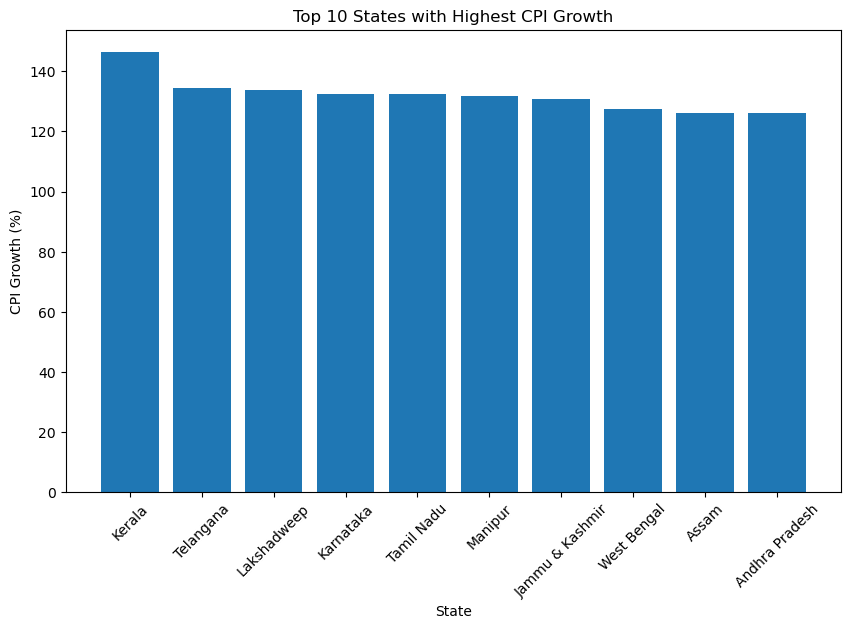

In [171]:
# Visualize top 10 states with highest CPI growth using a bar chart
# Bar charts are best for comparing categorical values like states

import matplotlib.pyplot as plt

top10_states = cpi_growth.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_states.index, top10_states['growth_percent'])
plt.xticks(rotation=45)
plt.title("Top 10 States with Highest CPI Growth")
plt.xlabel("State")
plt.ylabel("CPI Growth (%)")
plt.show()

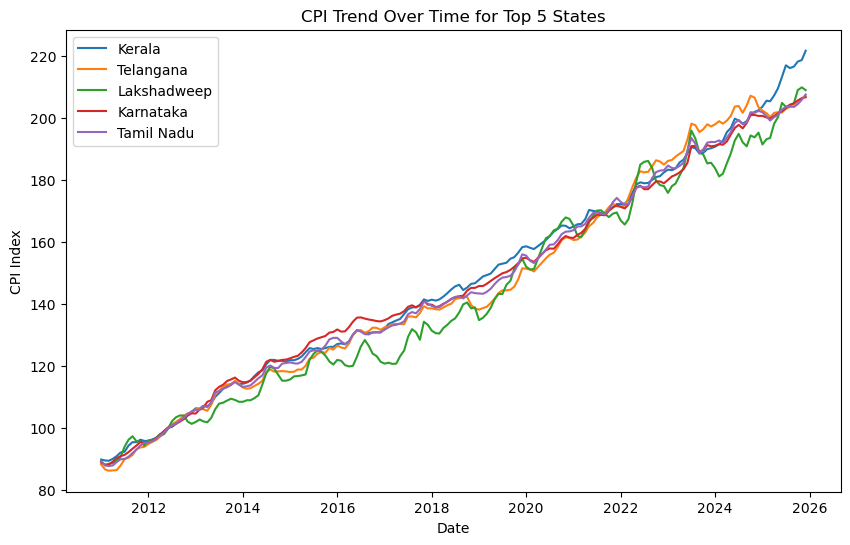

In [172]:
#CPI Trend for Top 5 States
import matplotlib.pyplot as plt

top5 = cpi_growth.head(5).index

plt.figure(figsize=(10,6))

for state in top5:
    data = df_states[df_states['state'] == state]
    plt.plot(data['date'], data['index'], label=state)

plt.legend()
plt.xlabel("Date")
plt.ylabel("CPI Index")
plt.title("CPI Trend Over Time for Top 5 States")
plt.show()

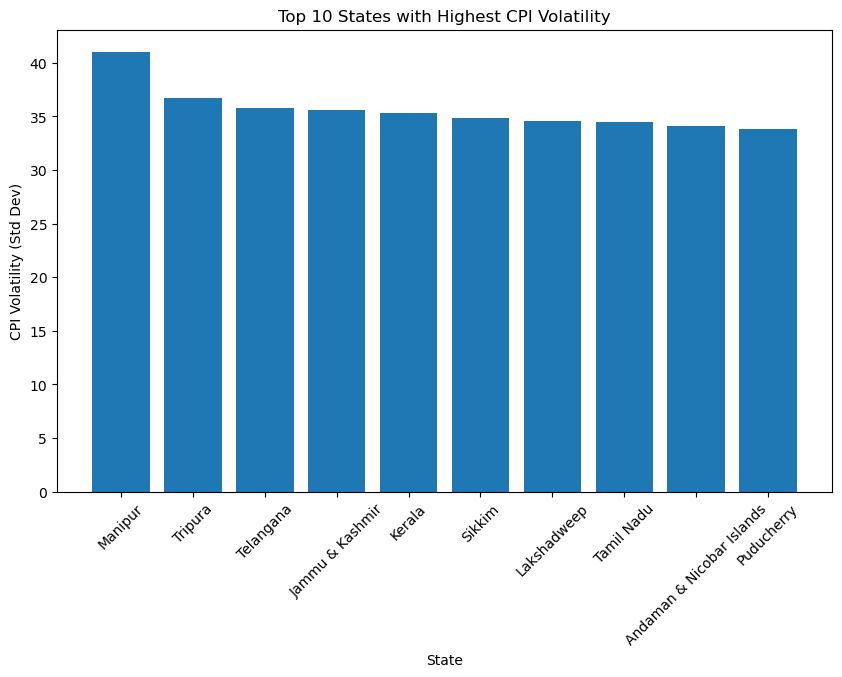

In [173]:
# To calculate Inflation Volatility Ranking
import matplotlib.pyplot as plt
top10_vol = cpi_volatility.head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_vol['state'], top10_vol['cpi_volatility'])
plt.xticks(rotation=45)
plt.title("Top 10 States with Highest CPI Volatility")
plt.xlabel("State")
plt.ylabel("CPI Volatility (Std Dev)")
plt.show()

In [175]:
#Forecasting
india_data = df_clean[df_clean['state'] == 'All India']

In [177]:
#TO set date as index
india_data = india_data.set_index('date')

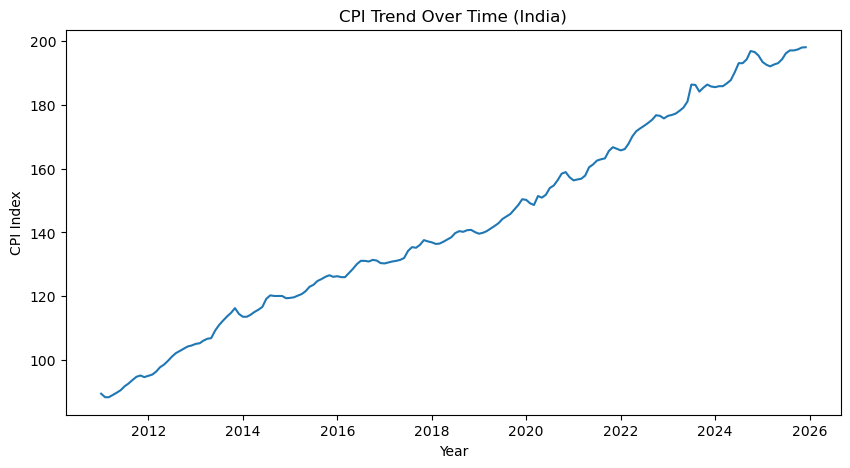

In [179]:
# CPI Trends 
#It shows long-term inflation trajectory
plt.figure(figsize=(10,5))
plt.plot(india_data['index'])
plt.title("CPI Trend Over Time (India)")
plt.xlabel("Year")
plt.ylabel("CPI Index")
plt.show()

In [180]:
india_data['forecast'] = india_data['index'].rolling(window=12).mean()

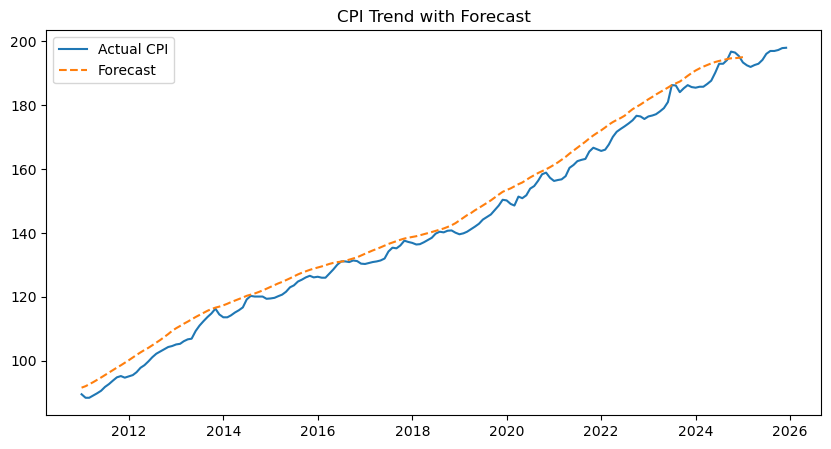

In [181]:
# Forecast plotting

plt.figure(figsize=(10,5))
plt.plot(india_data['index'], label="Actual CPI")
plt.plot(india_data['forecast'], label="Forecast", linestyle='--')
plt.legend()
plt.title("CPI Trend with Forecast")
plt.show()

In [186]:
final_cpi = df_states[['state','date','year','month','index']]

In [187]:
final_cpi = final_cpi.sort_values(['state','date']).reset_index(drop=True)
final_cpi.to_csv("clean_cpi_data.csv", index=False)

In [188]:
final_cpi.head()

,state,date,year,month,index
0,Andaman & Nicobar Islands,2011-01-01,2011,January,93.5
1,Andaman & Nicobar Islands,2011-02-01,2011,February,92.7
2,Andaman & Nicobar Islands,2011-03-01,2011,March,93.0
3,Andaman & Nicobar Islands,2011-04-01,2011,April,93.3
4,Andaman & Nicobar Islands,2011-05-01,2011,May,94.1


In [189]:
import os
os.getcwd()

'C:\\Users\\DELL\\Desktop\\India Inflation Intelligence Syatem'